implementation for laplacian eigen options on the four rooms environment. 

In [ ]:
#Imports

import numpy as np
import torch
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from tqdm import tqdm 
import math
import colorsys
import pickle

this cell holds all the hyperparameters used throughout.

In [55]:
HYPERPARAMS = {
    "gamma": 0.9,                  # Discount rate (used for both PI and SMDP)
    "alpha": 0.1,                  # Learning rate for SMDP Q-learning
    "epsilon_start": 1.0,          # Initial exploration rate
    "epsilon_min": 0.10,           # Minimum exploration rate
    "num_episodes": 5000,           # Total training episodes
    "max_steps": 200,              # Max steps per episode
    "num_options_to_use": 64       # 4 primitive + 64 options = 68 total actions
}

now we define our four rooms environment. 

In [56]:
class FourRoomsEnv(gym.Env):
    def __init__(self, bottleneck_rewards=False):
        super().__init__()

        self.grid_size = 11
        self.max_steps = 200
        self.bottleneck_rewards = bottleneck_rewards

        self.action_space = spaces.Discrete(4)

        self.observation_space = spaces.Box(
            low=0.0,
            high=float(self.grid_size),
            shape=(6,),
            dtype=np.float32,
        )

        self.goal_state = (0, 10)
        self.walls = set()

        for i in range(self.grid_size):
            self.walls.add((5, i))
            self.walls.add((i, 5))

        self.doorway_list = [(5, 1), (5, 8), (2, 5), (9, 5)]

        for doorway in self.doorway_list:
            self.walls.remove(doorway)

        self.valid_states = []
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                if (r, c) not in self.walls:
                    self.valid_states.append((r, c))

        self.state_to_idx = {
            state: idx for idx, state in enumerate(self.valid_states)
        }
        self.idx_to_state = {
            idx: state for state, idx in self.state_to_idx.items()
        }
        self.num_states = len(self.valid_states)

        self.current_state = None
        self.current_step = 0
        self.visited_doorways = set()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = 0
        self.visited_doorways.clear()

        idx = self.np_random.integers(0, len(self.valid_states))
        self.current_state = self.valid_states[idx]

        return self._get_obs(), {}

    def step(self, action):
        if isinstance(action, torch.Tensor):
            action = action.item()
        else:
            action = int(action)

        self.current_step += 1
        r, c = self.current_state

        if action == 0:
            r -= 1
        elif action == 1:
            c += 1
        elif action == 2:
            r += 1
        elif action == 3:
            c -= 1

        if (
            0 <= r < self.grid_size
            and 0 <= c < self.grid_size
            and (r, c) not in self.walls
        ):
            self.current_state = (r, c)

        terminated = self.current_state == self.goal_state
        truncated = self.current_step >= self.max_steps

        reward = 10.0 if terminated else 0.0

        if (
            self.bottleneck_rewards
            and self.current_state in self.doorway_list
            and self.current_state not in self.visited_doorways
        ):
            reward += 0.5
            self.visited_doorways.add(self.current_state)

        return self._get_obs(), reward, terminated, truncated, {}

    def _get_obs(self):
        r, c = self.current_state
        obs = [float(r), float(c)]

        for doorway in self.doorway_list:
            obs.append(
                1.0 if doorway in self.visited_doorways else 0.0
            )

        return np.array(obs, dtype=np.float32)

    def get_state_idx(self):
        return self.state_to_idx[self.current_state]

we'll build the adjacency matrix for the environment. 

In [57]:
def build_adjacency_matrix(env):
    num_states = env.num_states
    adjacency = np.zeros((num_states, num_states), dtype=np.float32)

    for state, state_idx in env.state_to_idx.items():
        r, c = state

        for action in range(env.action_space.n):
            next_r, next_c = r, c

            if action == 0:
                next_r -= 1
            elif action == 1:
                next_c += 1
            elif action == 2:
                next_r += 1
            elif action == 3:
                next_c -= 1

            if (
                0 <= next_r < env.grid_size
                and 0 <= next_c < env.grid_size
                and (next_r, next_c) not in env.walls
            ):
                next_state = (next_r, next_c)

                if next_state in env.state_to_idx:
                    next_idx = env.state_to_idx[next_state]

                    if state_idx != next_idx:
                        adjacency[state_idx, next_idx] = 1.0

    return adjacency

we'll build the degree matrix for the adjacency matrix. 

In [58]:
def build_degree_matrix(A):
    degrees = np.sum(A, axis=1)
    return np.diag(degrees)

we'll compute the normalized laplacian. 

In [59]:
def build_normalized_laplacian(A, D):
    degrees = np.diag(D)

    # Avoid division by zero for isolated nodes.
    d_inv_sqrt = 1.0 / np.sqrt(degrees + 1e-8)

    D_inv_sqrt = np.diag(d_inv_sqrt)

    return D_inv_sqrt @ (D - A) @ D_inv_sqrt

everything visualization is here.  

In [ ]:
import matplotlib as mpl
import matplotlib.patheffects as path_effects
from matplotlib.colors import LinearSegmentedColormap

#typography
FONT_STACK = {
    "title":      {"size": 13, "weight": "bold",   "color": "#1A1A2E"},
    "subtitle":   {"size": 9,  "weight": "normal", "color": "#6A6A7E", "style": "italic"},
    "axis_label": {"size": 10, "weight": "normal", "color": "#2C2C3E"},
    "tick":       {"size": 8,  "weight": "normal", "color": "#5A5A6E"},
    "legend":     {"size": 8,  "weight": "normal", "color": "#2C2C3E"},
    "annotation": {"size": 8,  "weight": "normal", "color": "#2C2C3E"},
    "caption":    {"size": 7,  "weight": "normal", "color": "#9A9AAE", "style": "italic"},
}

#color system
COLORS = {
    "primary":     "#1F3A5F",   #navy
    "secondary":   "#2E8B8B",   #teal
    "accent":      "#E4572E",   #warm coral
    "neutral":     "#8A8A9E",   #slate grey
    "positive":    "#2E8B8B",   #success teal
    "negative":    "#C73E1D",   #brick for warning
    "wall":        "#2C2C3E",   #charcoal
    "floor":       "#F2F2F5",   #light floor
    "grid":        "#E0E0E6",   #for subtle grids
    "background":  "#FAFAFC",   #off white
    "panel":       "#F4F4F7",   #for panel bg
    "text":        "#1A1A2E",   #almost black
    "text_muted":  "#7A7A8E",   #sober
    "start":       "#1F3A5F",   #for start
    "goal":        "#2E8B8B",   #for goal
    "primitive":   "#8A8A9E",   #for primitive actions
    "terminate":   "#E4572E",   #for termination markers
}

#okabe-ito categorical palette 
CATEGORICAL = [
    "#1F3A5F", "#E4572E", "#2E8B8B", "#F2A541",
    "#5C8A4E", "#8E5BA6", "#C73E1D", "#3A6EA5",
    "#D4A017", "#6B8E23", "#B85450", "#4A6FA5",
]

#palette for heatmaps
SEQUENTIAL = LinearSegmentedColormap.from_list(
    "pub_sequential",
    ["#FAFAFC", "#D6DFEC", "#8FA8C4", "#3A5F8F", "#1F3A5F", "#0D1F3A"],
)
SEQUENTIAL.set_bad("#2C2C3E")  # Walls shown as charcoal

#divering palettes for pvfs
DIVERGING = LinearSegmentedColormap.from_list(
    "pub_diverging",
    ["#1F3A5F", "#6E8FB8", "#D6DFEC", "#FAFAFC", "#F2C4A8", "#E8845A", "#E4572E"],
)
DIVERGING.set_bad("#2C2C3E")

#figure details
FIGURE = {
    "dpi":        120,
    "save_dpi":   300,
    "wspace":     0.35,
    "hspace":     0.45,
}

PLOT_DEFAULTS = {
    "grid_color":      COLORS["grid"],
    "grid_alpha":      0.5,
    "grid_linewidth":  0.5,
    "spine_color":     COLORS["text_muted"],
    "spine_linewidth": 0.7,
    "line_width":      1.5,
    "marker_size":     30,
    "alpha_raw":       0.25,
    "alpha_smooth":    0.9,
}

#global params
plt.rcParams.update({
    # Font
    "font.family":       "sans-serif",
    "font.sans-serif":   ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size":         10,
    # Text
    "text.color":        COLORS["text"],
    # Axes
    "axes.titlesize":    FONT_STACK["title"]["size"],
    "axes.titleweight":  FONT_STACK["title"]["weight"],
    "axes.titlecolor":   FONT_STACK["title"]["color"],
    "axes.titlepad":     8,
    "axes.labelsize":    FONT_STACK["axis_label"]["size"],
    "axes.labelcolor":   FONT_STACK["axis_label"]["color"],
    "axes.edgecolor":    PLOT_DEFAULTS["spine_color"],
    "axes.linewidth":    PLOT_DEFAULTS["spine_linewidth"],
    "axes.facecolor":    COLORS["background"],
    "axes.grid":         True,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    # Grid
    "grid.color":        PLOT_DEFAULTS["grid_color"],
    "grid.alpha":        PLOT_DEFAULTS["grid_alpha"],
    "grid.linewidth":    PLOT_DEFAULTS["grid_linewidth"],
    "grid.linestyle":    "-",
    # Ticks
    "xtick.color":       COLORS["text_muted"],
    "ytick.color":       COLORS["text_muted"],
    "xtick.labelsize":   FONT_STACK["tick"]["size"],
    "ytick.labelsize":   FONT_STACK["tick"]["size"],
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  3,
    "ytick.major.size":  3,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    # Legend
    "legend.fontsize":   FONT_STACK["legend"]["size"],
    "legend.frameon":    False,
    "legend.labelcolor": COLORS["text"],
    # Figure
    "figure.facecolor":  "white",
    "figure.dpi":        FIGURE["dpi"],
    "figure.autolayout": False,
    "savefig.dpi":       FIGURE["save_dpi"],
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
    # Scatter
    "scatter.marker":    "o",
})

#helpers
def style_axes(ax, grid=True, spines=("left", "bottom")):
    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(s in spines)
    ax.tick_params(colors=COLORS["text_muted"], which="both",
                   length=3, width=0.7)
    if grid:
        ax.grid(True, color=PLOT_DEFAULTS["grid_color"],
                alpha=PLOT_DEFAULTS["grid_alpha"],
                linewidth=PLOT_DEFAULTS["grid_linewidth"])
        ax.set_axisbelow(True)
    else:
        ax.grid(False)
    return ax

def style_colorbar(cbar):
    cbar.ax.tick_params(colors=COLORS["text_muted"],
                        labelsize=FONT_STACK["tick"]["size"],
                        length=2, width=0.5)
    cbar.outline.set_edgecolor(COLORS["text_muted"])
    cbar.outline.set_linewidth(0.5)
    return cbar

def set_title(ax, title, subtitle=None):
    pad = 28 if subtitle else 8  
    ax.set_title(title, loc="left", pad=pad,
                 fontsize=FONT_STACK["title"]["size"],
                 fontweight=FONT_STACK["title"]["weight"],
                 color=FONT_STACK["title"]["color"])
    if subtitle:
        ax.text(0, 1.05, subtitle, transform=ax.transAxes,
                fontsize=FONT_STACK["subtitle"]["size"],
                color=FONT_STACK["subtitle"]["color"],
                style=FONT_STACK["subtitle"]["style"],
                ha="left", va="bottom")

def fig_title(fig, title, subtitle=None, y=0.99):
    fig.suptitle(title, x=0.01, y=y, ha="left", va="top",
                 fontsize=FONT_STACK["title"]["size"] + 2,
                 fontweight=FONT_STACK["title"]["weight"],
                 color=FONT_STACK["title"]["color"])
    if subtitle:
        offset = 0.5 / fig.get_figheight() 
        fig.text(0.01, y - offset, subtitle, ha="left", va="top",
                 fontsize=FONT_STACK["subtitle"]["size"],
                 color=FONT_STACK["subtitle"]["color"],
                 style=FONT_STACK["subtitle"]["style"])

def option_color(opt_idx, total=64):
    hue = (opt_idx * 0.381966) % 1.0  #golden-ratio for even spread
    return colorsys.hls_to_rgb(hue, 0.52, 0.55)

def draw_env_grid(ax, env, coord_system="inverted"):
    if coord_system == "inverted":
        yt = lambda r: env.grid_size - 1 - r
        offset = -0.5
        lim_lo, lim_hi = -0.5, env.grid_size - 0.5
    else:
        yt = lambda r: r
        offset = 0
        lim_lo, lim_hi = 0, env.grid_size

    #floor tiles
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            if (r, c) not in env.walls:
                ax.add_patch(plt.Rectangle(
                    (c + offset, yt(r) + offset), 1, 1,
                    facecolor=COLORS["floor"],
                    edgecolor=COLORS["grid"],
                    linewidth=0.3, zorder=1,
                ))

    #walls
    for (r, c) in env.walls:
        ax.add_patch(plt.Rectangle(
            (c + offset, yt(r) + offset), 1, 1,
            facecolor=COLORS["wall"], edgecolor="none", zorder=2,
        ))

    #goal
    gr, gc = env.goal_state
    ax.add_patch(plt.Rectangle(
        (gc + offset, yt(gr) + offset), 1, 1,
        facecolor=COLORS["goal"], alpha=0.18, edgecolor="none", zorder=2,
    ))

    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    if coord_system == "natural":
        ax.set_ylim(lim_hi, lim_lo)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(False)
    ax.grid(False)
    ax.set_facecolor(COLORS["background"])
    return ax

#old config
VIZ_CONFIG = {
    "fig_size": (10, 6),
    "cmap_matrices": SEQUENTIAL,
    "cmap_heatmaps": DIVERGING,
    "font_size": 10,
    "title_color": COLORS["text"],
}

In [61]:
def generate_option_colors(num_options=64):
    """Generates distinct, perceptually balanced colors using the golden ratio."""
    return [option_color(i, num_options) for i in range(num_options)]

def plot_episode_trajectories(env, trajectory_log, save_path=None):
    """Plots episode trajectories on the Four Rooms grid (legacy interface)."""
    option_colors = generate_option_colors(64)

    episodes = sorted(trajectory_log.keys())
    n_eps = len(episodes)
    if n_eps == 0:
        print("No episodes to plot.")
        return

    n_cols = int(np.ceil(np.sqrt(n_eps)))
    n_rows = int(np.ceil(n_eps / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    if n_eps == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, ep in enumerate(episodes):
        ax = axes[idx]
        data = trajectory_log[ep]
        steps = data['steps']
        truncated = data.get('truncated', False)

        draw_env_grid(ax, env, coord_system="inverted")

        # Trajectories
        for step in steps:
            action_type = step['action_type']
            action_id = step['action_id']
            states = step['states']

            if action_type == 'primitive':
                color = COLORS["primitive"]
            else:
                color = option_colors[action_id % 64]

            for i in range(len(states) - 1):
                r1, c1 = states[i]
                r2, c2 = states[i + 1]

                x1, y1 = c1, env.grid_size - 1 - r1
                x2, y2 = c2, env.grid_size - 1 - r2

                if (r1, c1) == (r2, c2):
                    circle = plt.Circle((x1, y1), 0.1, color=color, alpha=0.8, zorder=4)
                    ax.add_patch(circle)
                else:
                    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                                arrowprops=dict(arrowstyle="->", color=color,
                                                lw=1.2, alpha=0.85,
                                                shrinkA=5, shrinkB=5))

        # Start & Goal markers
        start_state = data['start_state']
        goal_state = env.goal_state

        sx, sy = start_state[1], env.grid_size - 1 - start_state[0]
        gx, gy = goal_state[1], env.grid_size - 1 - goal_state[0]

        ax.text(sx, sy, 'S', ha='center', va='center', fontsize=10,
                fontweight='bold', color=COLORS["start"], zorder=6,
                path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
        ax.text(gx, gy, 'G', ha='center', va='center', fontsize=10,
                fontweight='bold', color=COLORS["goal"], zorder=6,
                path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])

        title = f"Episode {ep}  ({len(steps)} steps)"
        if truncated:
            title += "  \u00b7  Truncated"
        set_title(ax, title)
    
    for idx in range(n_eps, len(axes)):
        axes[idx].axis('off')

    fig_title(fig, "Episode Trajectories", "Agent behaviour across training episodes")
    
    top_margin = 1.0 - (1.0 / (n_rows * 4))
    plt.tight_layout(rect=[0, 0, 1, top_margin])
    
    if save_path:
        plt.savefig(save_path, dpi=FIGURE["save_dpi"], bbox_inches='tight')
        print(f"Trajectories saved to {save_path}")
    plt.show()

lets visualize the created matrices 

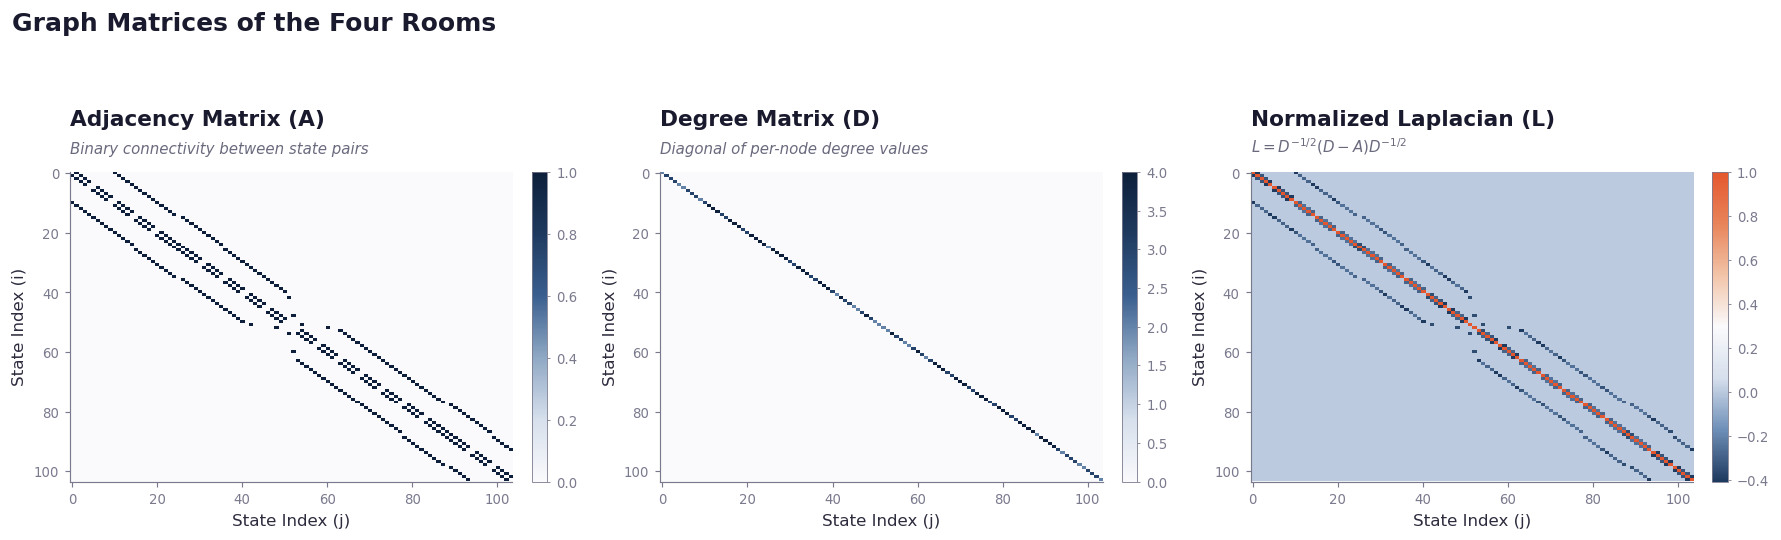

In [62]:
def plot_graph_matrices(env):
    adjacency = build_adjacency_matrix(env)
    degree = build_degree_matrix(adjacency)
    laplacian = build_normalized_laplacian(adjacency, degree)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.subplots_adjust(wspace=0.45)

    matrices = [
        (adjacency, "Adjacency Matrix (A)",
         "Binary connectivity between state pairs", SEQUENTIAL),
        (degree, "Degree Matrix (D)",
         "Diagonal of per-node degree values", SEQUENTIAL),
        (laplacian, "Normalized Laplacian (L)",
         r"$L = D^{-1/2}(D-A)D^{-1/2}$", DIVERGING),
    ]

    for ax, (mat, title, subtitle, cmap) in zip(axes, matrices):
        im = ax.imshow(mat, cmap=cmap, aspect="auto", interpolation="nearest")
        set_title(ax, title, subtitle)
        ax.set_xlabel("State Index (j)", fontsize=FONT_STACK["axis_label"]["size"],
                      color=FONT_STACK["axis_label"]["color"])
        ax.set_ylabel("State Index (i)", fontsize=FONT_STACK["axis_label"]["size"],
                      color=FONT_STACK["axis_label"]["color"])
        style_axes(ax, grid=False, spines=("left", "bottom"))
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        style_colorbar(cbar)

    fig_title(fig, "Graph Matrices of the Four Rooms")
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


env = FourRoomsEnv()
plot_graph_matrices(env)

now we do eigendecomposition on the normalized laplacian and get our protovalue functions (PVFs)

In [63]:
def compute_pvfs(L, discard_first=True):
    eigenvalues, eigenvectors = np.linalg.eigh(L)

    idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # The first eigenvector is the trivial constant solution.
    if discard_first:
        eigenvalues = eigenvalues[1:]
        eigenvectors = eigenvectors[:, 1:]

    return eigenvalues, eigenvectors

now we'll refine our eigenpurposes, which are just the intrinsic reward functions

In [64]:
def get_intrinsic_reward(eigenpurpose_vector, current_state_idx, next_state_idx):
    return eigenpurpose_vector[next_state_idx] - eigenpurpose_vector[current_state_idx]

lets visualize our eigenpurposes. 

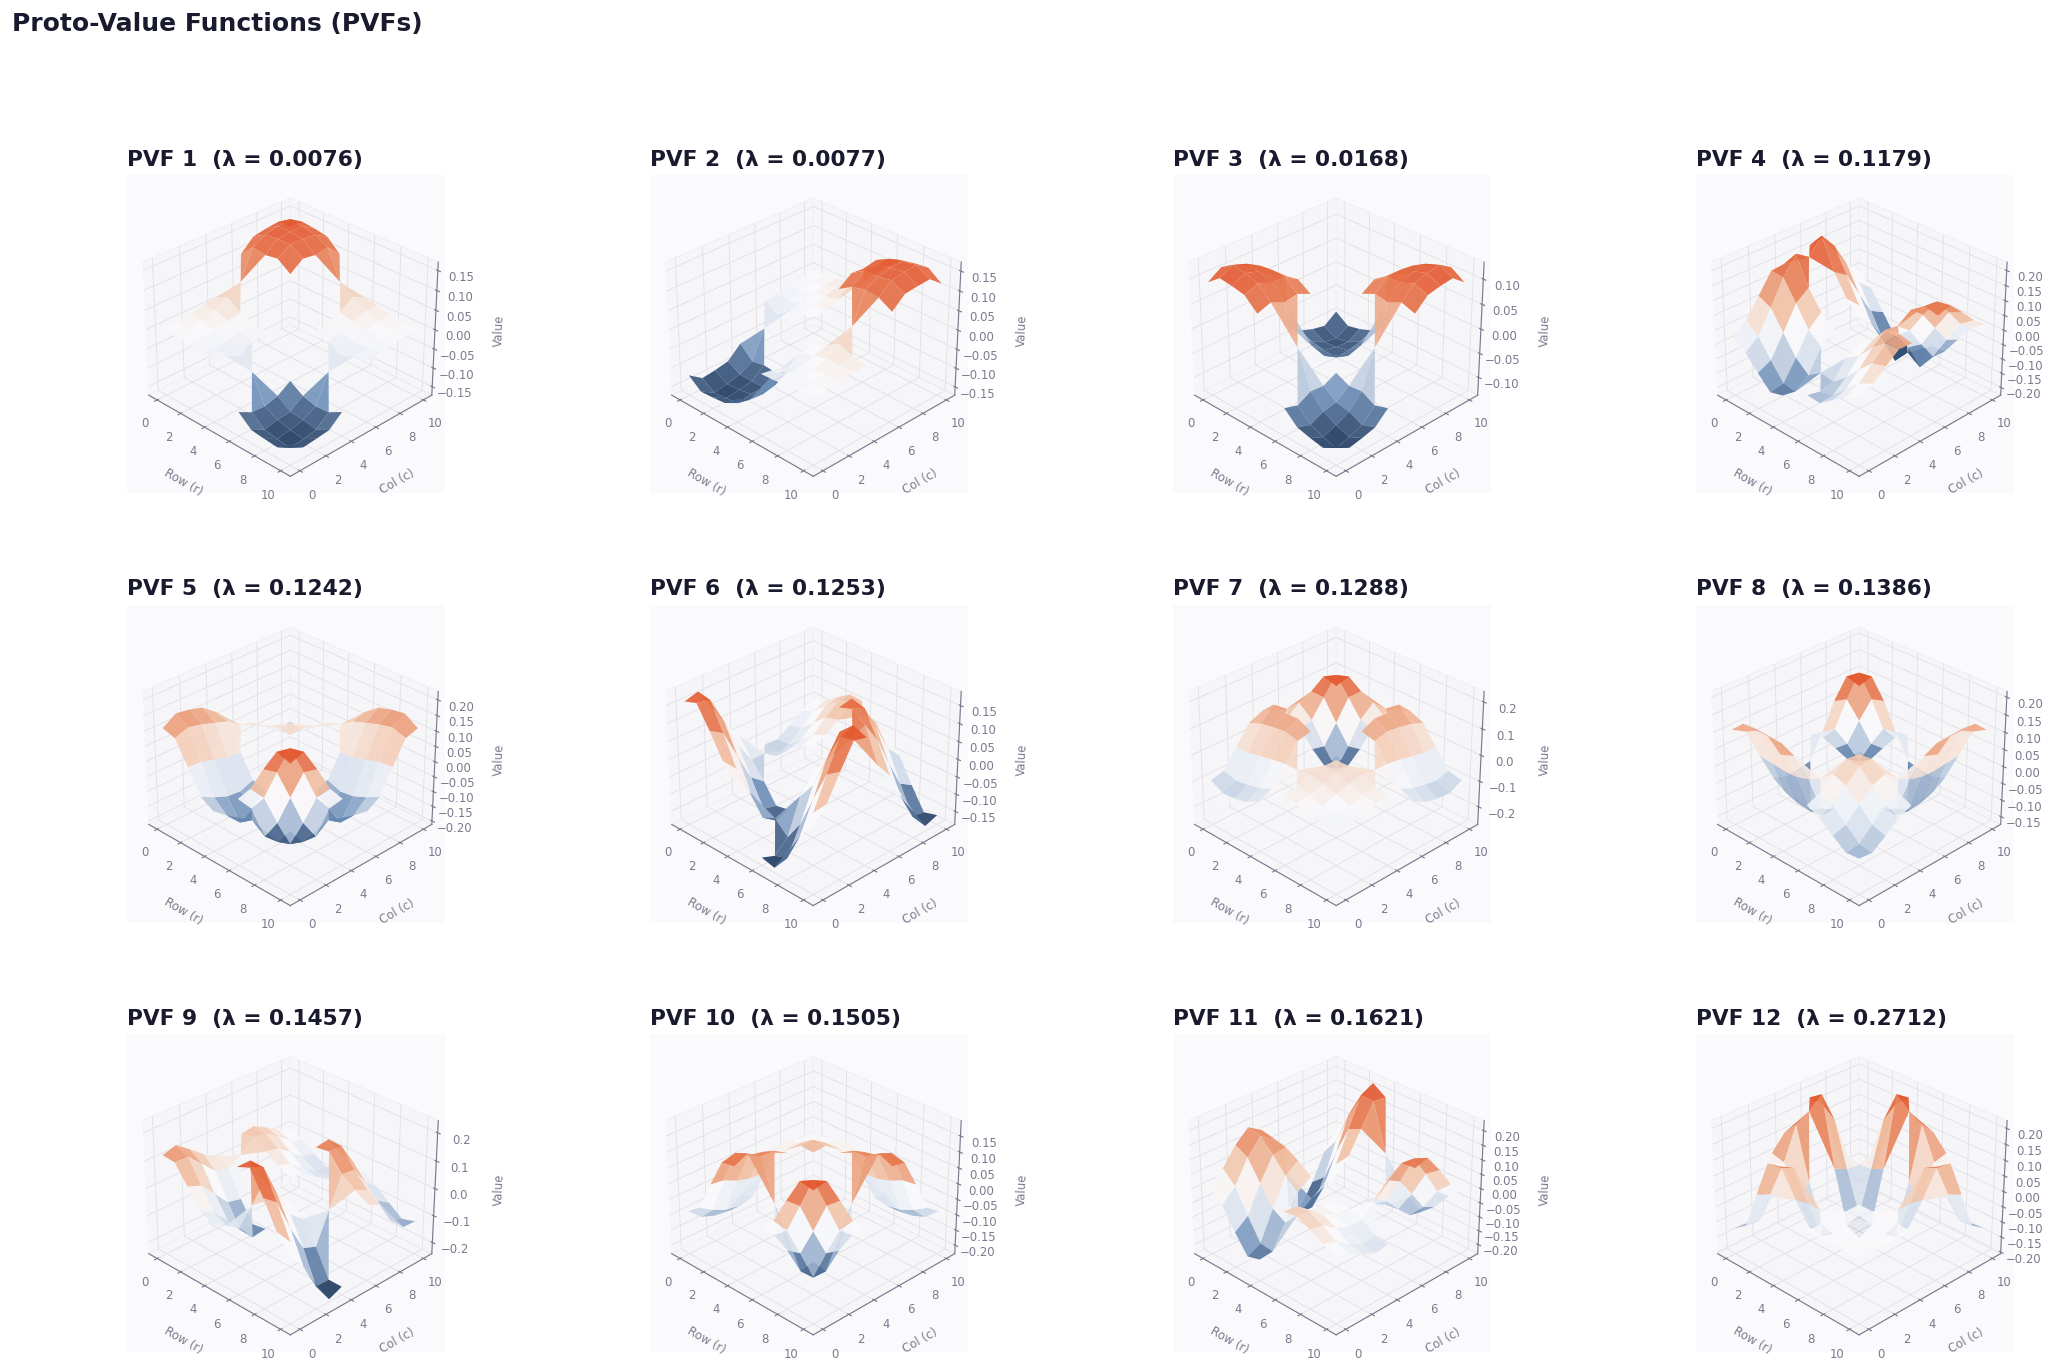

In [65]:
def reshape_pvf_to_2d(env, pvf):
    grid = np.full((env.grid_size, env.grid_size), np.nan)

    for state, state_idx in env.state_to_idx.items():
        r, c = state
        grid[r, c] = pvf[state_idx]

    return grid


def plot_pvfs_3d(env, eigenvalues, eigenvectors, num_to_plot=4):
    n_cols = int(np.ceil(np.sqrt(num_to_plot)))
    n_rows = int(np.ceil(num_to_plot / n_cols))

    fig = plt.figure(figsize=(4.5 * n_cols, 3.8 * n_rows))

    X, Y = np.meshgrid(
        np.arange(env.grid_size),
        np.arange(env.grid_size),
    )

    for i in range(num_to_plot):
        pvf = eigenvectors[:, i]
        Z = reshape_pvf_to_2d(env, pvf)

        ax = fig.add_subplot(n_rows, n_cols, i + 1, projection="3d")

        ax.plot_surface(
            X, Y, Z,
            cmap=DIVERGING,
            edgecolor="none",
            alpha=0.9,
            linewidth=0,
            antialiased=True,
            rstride=1, cstride=1,
        )

        ax.set_title(
            f"PVF {i + 1}  (\u03bb = {eigenvalues[i]:.4f})",
            loc="left", pad=6,
            fontsize=FONT_STACK["title"]["size"],
            fontweight=FONT_STACK["title"]["weight"],
            color=FONT_STACK["title"]["color"],
        )
        ax.set_xlabel("Row (r)", fontsize=7,
                      color=COLORS["text_muted"], labelpad=1)
        ax.set_ylabel("Col (c)", fontsize=7,
                      color=COLORS["text_muted"], labelpad=1)
        ax.set_zlabel("Value", fontsize=7,
                      color=COLORS["text_muted"], labelpad=1)

        ax.tick_params(colors=COLORS["text_muted"], labelsize=7, pad=0)
        for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
            pane.set_facecolor(COLORS["panel"])
            pane.set_edgecolor(COLORS["grid"])
            pane.set_linewidth(0.4)
        ax.grid(True, alpha=0.25, linewidth=0.3)

        ax.view_init(elev=30, azim=-45)

    fig_title(fig, "Proto-Value Functions (PVFs)",
              y=1.02)
    # Manual adjustment is safer than tight_layout for 3D plots to prevent overlap
    plt.subplots_adjust(top=0.90, bottom=0.04, left=0.04, right=0.96, wspace=0.25, hspace=0.35)
    plt.show()


env = FourRoomsEnv()

A = build_adjacency_matrix(env)
D = build_degree_matrix(A)
L = build_normalized_laplacian(A, D)

eigenvalues, eigenvectors = compute_pvfs(
    L,
    discard_first=True,
)

plot_pvfs_3d(
    env,
    eigenvalues,
    eigenvectors,
    num_to_plot=12,
)

now we'll use policy iteration to train our eigenbehaviours (basically just options). first we define the transition dynamics

In [66]:
def get_deterministic_next_state(env, state_idx, action):
    state = env.idx_to_state[state_idx]
    r, c = state

    next_r, next_c = r, c

    if action == 0:
        next_r -= 1
    elif action == 1:
        next_c += 1
    elif action == 2:
        next_r += 1
    elif action == 3:
        next_c -= 1

    if (
        0 <= next_r < env.grid_size
        and 0 <= next_c < env.grid_size
        and (next_r, next_c) not in env.walls
    ):
        next_state = (next_r, next_c)
    else:
        next_state = state

    return env.state_to_idx[next_state]

now, policy iteration.

In [67]:
def policy_iteration_eigenoption(
    env,
    eigenpurpose_vector,
    gamma=0.9,
    max_iters=1000,
    tol=1e-6,
):
    num_states = env.num_states
    num_actions = 4

    policy = np.random.randint(
        0,
        num_actions,
        size=num_states,
    )
    V = np.zeros(num_states)

    for _ in range(max_iters):
        for _ in range(1000):
            delta = 0.0
            new_V = np.zeros(num_states)

            for state_idx in range(num_states):
                action = policy[state_idx]

                if action == 4:
                    new_V[state_idx] = 0.0
                else:
                    next_state_idx = get_deterministic_next_state(
                        env,
                        state_idx,
                        action,
                    )

                    reward = (
                        eigenpurpose_vector[next_state_idx]
                        - eigenpurpose_vector[state_idx]
                    )

                    new_V[state_idx] = (
                        reward
                        + gamma * V[next_state_idx]
                    )

                delta = max(
                    delta,
                    abs(new_V[state_idx] - V[state_idx]),
                )

            V = new_V

            if delta < tol:
                break

        policy_stable = True
        Q = np.zeros((num_states, num_actions + 1))

        for state_idx in range(num_states):
            old_action = policy[state_idx]

            for action in range(num_actions):
                next_state_idx = get_deterministic_next_state(
                    env,
                    state_idx,
                    action,
                )

                reward = (
                    eigenpurpose_vector[next_state_idx]
                    - eigenpurpose_vector[state_idx]
                )

                Q[state_idx, action] = (
                    reward
                    + gamma * V[next_state_idx]
                )

            Q[state_idx, 4] = 0.0

            best_action = np.argmax(Q[state_idx])
            policy[state_idx] = best_action

            if old_action != best_action:
                policy_stable = False

        if policy_stable:
            break

    initiation_set = []
    termination_set = []

    for state_idx in range(num_states):
        max_primitive_q = np.max(Q[state_idx, :4])

        if max_primitive_q > 0:
            initiation_set.append(state_idx)
            policy[state_idx] = np.argmax(Q[state_idx, :4])
        else:
            policy[state_idx] = 4
            termination_set.append(state_idx)

    return {
        "policy": policy,
        "Q": Q,
        "initiation_set": initiation_set,
        "termination_set": termination_set,
    }

training loop to build the option bank

In [68]:
def build_option_bank(
    env,
    eigenvalues,
    eigenvectors,
    gamma,
):
    options_bank = []
    num_eigenvectors = eigenvectors.shape[1]

    for i in range(num_eigenvectors):
        pvf = eigenvectors[:, i]

        print(
            f"Training Option "
            f"{len(options_bank) + 1}/{num_eigenvectors * 2} "
            f"(Eigenvector {i + 1} - Uphill)"
        )

        option_positive = policy_iteration_eigenoption(
            env,
            pvf,
            gamma=gamma,
        )

        options_bank.append({
            "id": len(options_bank),
            "eigenvalue": eigenvalues[i],
            "direction": "positive",
            "policy": option_positive["policy"],
            "initiation_set": option_positive["initiation_set"],
            "termination_set": option_positive["termination_set"],
        })

        print(
            f"Training Option "
            f"{len(options_bank) + 1}/{num_eigenvectors * 2} "
            f"(Eigenvector {i + 1} - Downhill)"
        )

        option_negative = policy_iteration_eigenoption(
            env,
            -pvf,
            gamma=gamma,
        )

        options_bank.append({
            "id": len(options_bank),
            "eigenvalue": eigenvalues[i],
            "direction": "negative",
            "policy": option_negative["policy"],
            "initiation_set": option_negative["initiation_set"],
            "termination_set": option_negative["termination_set"],
        })

    print("Option Bank construction complete!")
    return options_bank


options_bank = build_option_bank(
    env,
    eigenvalues,
    eigenvectors,
    gamma=HYPERPARAMS["gamma"],
)

print(f"Total options stored in bank: {len(options_bank)}")

Training Option 1/206 (Eigenvector 1 - Uphill)
Training Option 2/206 (Eigenvector 1 - Downhill)
Training Option 3/206 (Eigenvector 2 - Uphill)
Training Option 4/206 (Eigenvector 2 - Downhill)
Training Option 5/206 (Eigenvector 3 - Uphill)
Training Option 6/206 (Eigenvector 3 - Downhill)
Training Option 7/206 (Eigenvector 4 - Uphill)
Training Option 8/206 (Eigenvector 4 - Downhill)
Training Option 9/206 (Eigenvector 5 - Uphill)
Training Option 10/206 (Eigenvector 5 - Downhill)
Training Option 11/206 (Eigenvector 6 - Uphill)
Training Option 12/206 (Eigenvector 6 - Downhill)
Training Option 13/206 (Eigenvector 7 - Uphill)
Training Option 14/206 (Eigenvector 7 - Downhill)
Training Option 15/206 (Eigenvector 8 - Uphill)
Training Option 16/206 (Eigenvector 8 - Downhill)
Training Option 17/206 (Eigenvector 9 - Uphill)
Training Option 18/206 (Eigenvector 9 - Downhill)
Training Option 19/206 (Eigenvector 10 - Uphill)
Training Option 20/206 (Eigenvector 10 - Downhill)
Training Option 21/206 (Eig

visualizing policies of learned eigenbehaviours

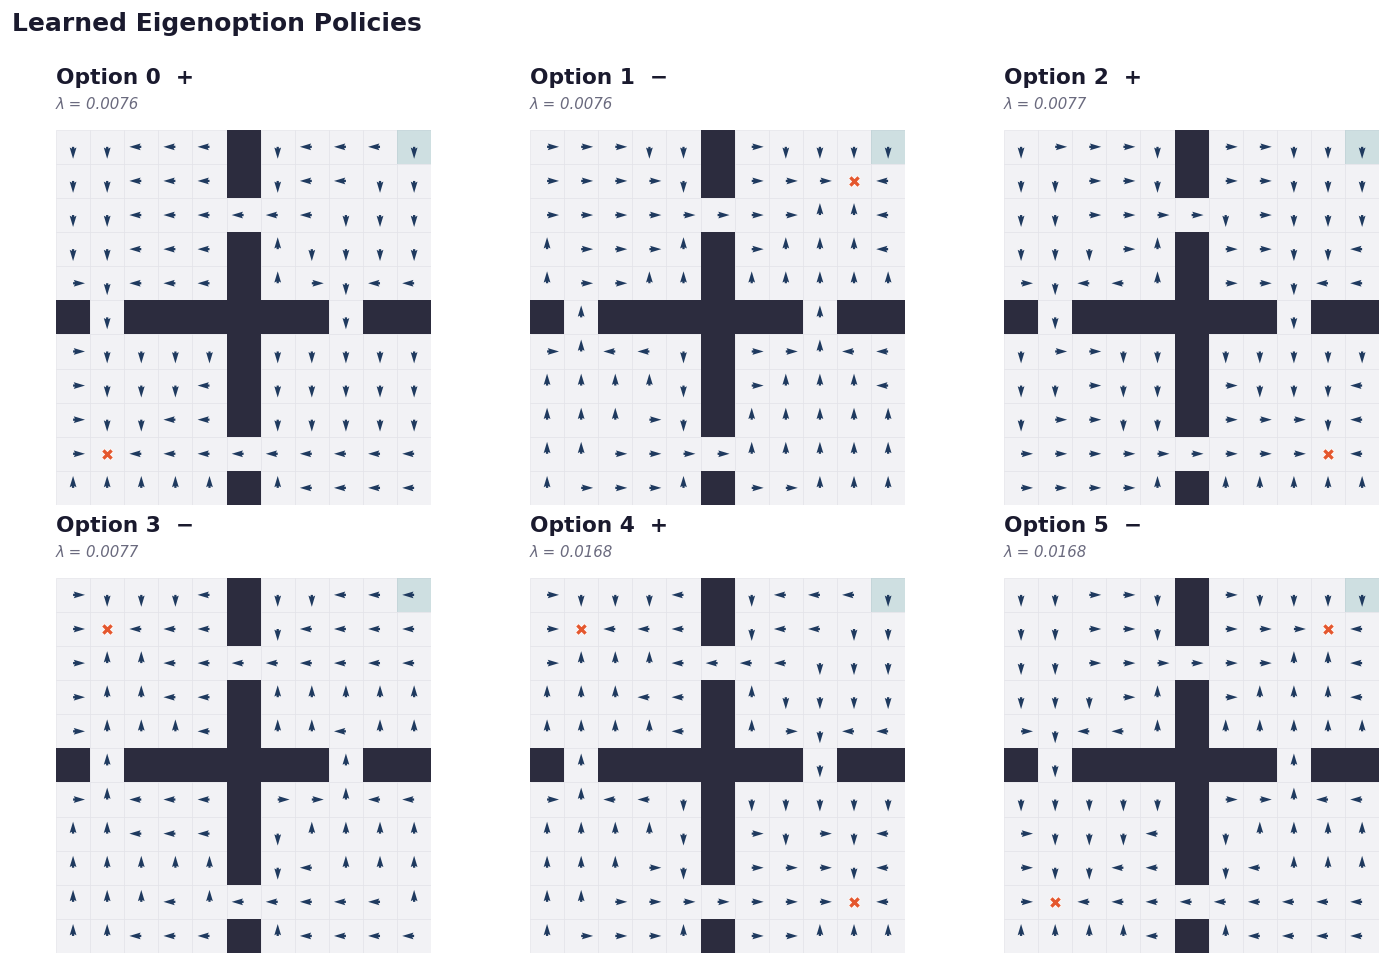

In [69]:
def plot_eigenoption_policies(env, options_list, n_cols=3):
    num_options = len(options_list)
    n_rows = int(np.ceil(num_options / n_cols))

    fig_width = 4 * n_cols
    fig_height = 4 * n_rows

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
    if num_options == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    arrow_len = 0.35
    action_to_uv = {
        0: (0.0, +arrow_len),
        1: (+arrow_len, 0.0),
        2: (0.0, -arrow_len),
        3: (-arrow_len, 0.0),
    }

    for i, option_data in enumerate(options_list):
        ax = axes[i]
        policy = option_data["policy"]
        draw_env_grid(ax, env, coord_system="inverted")

        X, Y, U, V = [], [], [], []

        for state, state_idx in env.state_to_idx.items():
            r, c = state
            x = c
            y = env.grid_size - 1 - r
            action = policy[state_idx]

            if action == 4:
                ax.scatter(x, y, color=COLORS["terminate"], marker="X",
                           s=50, zorder=5, edgecolors="white", linewidths=0.5)
            else:
                du, dv = action_to_uv[action]
                X.append(x)
                Y.append(y)
                U.append(du)
                V.append(dv)

        if X:
            ax.quiver(X, Y, U, V, angles="xy", scale_units="xy", scale=1,
                      color=COLORS["primary"], width=0.006, zorder=4)

        direction_sym = "+" if option_data["direction"] == "positive" else "\u2212"
        set_title(ax,
                  f"Option {option_data['id']}  {direction_sym}",
                  f"\u03bb = {option_data['eigenvalue']:.4f}")

    for ax in axes[num_options:]:
        ax.axis("off")

    fig_title(fig, "Learned Eigenoption Policies",
              y=1.0)
    plt.tight_layout()
    plt.show()


options_to_plot = options_bank[0:6]

plot_eigenoption_policies(
    env,
    options_to_plot,
    n_cols=3,
)

we'll prepare the options for training 

In [70]:
def prepare_smdp_options(options_bank, num_options):

    #sort by eigenvalue
    sorted_options = sorted(options_bank, key=lambda x: x['eigenvalue'])
    
    selected_options = sorted_options[:num_options]
    
    print(f"Selected {len(selected_options)} options out of {len(options_bank)}.")
    print(f"Eigenvalue range: {selected_options[0]['eigenvalue']:.4f} to {selected_options[-1]['eigenvalue']:.4f}")
    
    return selected_options

smdp_options = prepare_smdp_options(options_bank, HYPERPARAMS["num_options_to_use"])

Selected 64 options out of 206.
Eigenvalue range: 0.0076 to 0.7170


we'll train the agent in the actual env using smdp-q learning

In [71]:
def smdp_q_learning(env, options, hyperparams):
    num_states = env.num_states
    num_primitive = 4
    num_options = len(options)
    total_actions = num_primitive + num_options  #4 + 64 = 68
    
    #q-table
    Q_table = np.zeros((num_states, total_actions))
    
    epsilon = hyperparams["epsilon_start"]
    epsilon_min = hyperparams["epsilon_min"]
    epsilon_decay = hyperparams["epsilon_start"] / (hyperparams["num_episodes"] / 2)
    
    alpha = hyperparams["alpha"]
    gamma = hyperparams["gamma"]
    
    episode_rewards = []
    episode_steps = []
    
    for episode in tqdm(range(hyperparams["num_episodes"]), desc="Training SMDP Agent"):
        obs, _ = env.reset()
        state_idx = env.get_state_idx()
        
        total_reward = 0
        step = 0
        
        while step < hyperparams["max_steps"]:
            #e-greedy action selection
            if np.random.rand() < epsilon:
                action_idx = np.random.randint(0, total_actions)
            else:
                action_idx = np.argmax(Q_table[state_idx, :])
                
            if action_idx < num_primitive:
                #primitive actions
                next_obs, reward, terminated, truncated, _ = env.step(action_idx)
                next_state_idx = env.get_state_idx()
                
                #1 step q learning
                target = reward + (0 if terminated else gamma * np.max(Q_table[next_state_idx, :]))
                Q_table[state_idx, action_idx] += alpha * (target - Q_table[state_idx, action_idx])
                
                state_idx = next_state_idx
                total_reward += reward
                step += 1
                
                if terminated or truncated:
                    break
            else:
                #options
                option_idx = action_idx - num_primitive
                option = options[option_idx]
                option_policy = option['policy']
                start_state_idx = state_idx 
                
                k = 0
                option_reward = 0.0
                
                while True:
                    #checking if option terminates
                    if option_policy[state_idx] == 4:
                        break
                    
                    primitive_action = option_policy[state_idx]
                    next_obs, reward, terminated, truncated, _ = env.step(primitive_action)
                    next_state_idx = env.get_state_idx()
                
                    option_reward += (gamma ** k) * reward
                    k += 1
                    
                    state_idx = next_state_idx
                    total_reward += reward
                    step += 1
                    
                    if terminated or truncated:
                        break
                    if step >= hyperparams["max_steps"]:
                        break
                
                #q learning update
                bootstrapped_value = 0.0
                if not (terminated or truncated):
                    bootstrapped_value = np.max(Q_table[state_idx, :])
                    
                target = option_reward + (gamma ** k) * bootstrapped_value
                
                
                Q_table[start_state_idx, action_idx] += alpha * (target - Q_table[start_state_idx, action_idx])
                
                if terminated or truncated:
                    break
                    
        #epsilon decay
        epsilon = max(epsilon_min, epsilon - epsilon_decay)
        episode_rewards.append(total_reward)
        episode_steps.append(step)
        
    return Q_table, episode_rewards, episode_steps

#training
train_env = FourRoomsEnv()

print("Starting SMDP Q-Learning Training...")
master_Q_table, smdp_rewards, smdp_steps = smdp_q_learning(train_env, smdp_options, HYPERPARAMS)
print("Training Complete!")

Starting SMDP Q-Learning Training...


Training SMDP Agent: 100%|██████████| 5000/5000 [00:00<00:00, 8393.25it/s]

Training Complete!


preparing for plotting episodic trajectories to better understand option selection

In [72]:
def get_action_color(action):
    if action < 4:
        return COLORS["primitive"]
    else:
        opt_idx = action - 4
        return option_color(opt_idx)

def plot_episode_trajectories(trajectories, env, options_list, start_ep, end_ep, save_path="trajectories.png"):

    episodes_to_plot = [ep for ep in range(start_ep, end_ep + 1) if ep in trajectories]
    n_eps = len(episodes_to_plot)
    
    if n_eps == 0:
        print(f"No trajectories found between episodes {start_ep} and {end_ep}.")
        return
        
    cols = min(5, n_eps)
    rows = math.ceil(n_eps / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5.0, rows * 4.5))
    if n_eps == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, ep in enumerate(episodes_to_plot):
        ax = axes[idx]
        traj = trajectories[ep]
        
        if not traj:
            ax.axis('off')
            continue
            
        #title generator
        used_options = sorted(list(set(step['high_level_action'] for step in traj if step['high_level_action'] >= 4)))
        
        title_str = f"Episode {ep}"
        
        if used_options:
            opt_strs = []
            for act in used_options:
                opt_idx = act - 4
                opt_data = options_list[opt_idx]
                
                dir_sym = "+" if opt_data['direction'] == "positive" else "\u2212"
                
                opt_strs.append(f"{opt_idx}(\u03bb={opt_data['eigenvalue']:.3f},{dir_sym})")
            
            title_str += f"\nOpts: {', '.join(opt_strs)}"
        else:
            title_str += "\n(Primitives Only)"
            
        ax.set_title(title_str, fontsize=8, weight='bold',
                     color=COLORS["text"], loc="left", pad=6)
        
        #grid + walls
        ax.set_xlim(0, env.grid_size)
        ax.set_ylim(env.grid_size, 0)
        ax.set_aspect('equal')
        ax.set_xticks(np.arange(env.grid_size))
        ax.set_yticks(np.arange(env.grid_size))
        ax.grid(color=COLORS["grid"], linestyle='-', linewidth=0.4, alpha=0.5)
        ax.set_axisbelow(True)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        for s in ["top", "right", "left", "bottom"]:
            ax.spines[s].set_visible(False)
        ax.set_facecolor(COLORS["floor"])
        
        #walls
        for (r, c) in env.walls:
            rect = mpatches.Rectangle((c, r), 1, 1, facecolor=COLORS["wall"],
                                      edgecolor="none")
            ax.add_patch(rect)
            
        #mark goal
        gr, gc = env.goal_state
        ax.add_patch(mpatches.Rectangle((gc, gr), 1, 1,
                                        facecolor=COLORS["goal"], alpha=0.18,
                                        edgecolor="none"))
        
        start_state = traj[0]['transitions'][0][0]
        ax.text(start_state[1] + 0.5, start_state[0] + 0.5, 'S',
                color=COLORS["start"], weight='bold', fontsize=11,
                ha='center', va='center', zorder=6,
                path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
        
        goal_state = env.goal_state
        ax.text(goal_state[1] + 0.5, goal_state[0] + 0.5, 'G',
                color=COLORS["goal"], weight='bold', fontsize=11,
                ha='center', va='center', zorder=6,
                path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
                
        #transitions
        for step in traj:
            action = step['high_level_action']
            color = get_action_color(action)
            
            #highlighter effect 
            if step['transitions']:
            
                path_x = [step['transitions'][0][0][1] + 0.5]
                path_y = [step['transitions'][0][0][0] + 0.5]
                
                for (state, next_state) in step['transitions']:
                    path_x.append(next_state[1] + 0.5)
                    path_y.append(next_state[0] + 0.5)
                
                #opaque background line
                ax.plot(path_x, path_y, color=color, linewidth=12, alpha=0.25,
                        solid_capstyle='round', solid_joinstyle='round', zorder=3)


            for (state, next_state) in step['transitions']:
                y1, x1 = state[0] + 0.5, state[1] + 0.5
                y2, x2 = next_state[0] + 0.5, next_state[1] + 0.5
                
                arrow = mpatches.FancyArrowPatch(
                    (x1, y1), (x2, y2),
                    color=color, mutation_scale=8, arrowstyle='-|>',
                    shrinkA=5, shrinkB=5, linewidth=1.2, zorder=4,
                    alpha=0.85,
                )
                ax.add_patch(arrow)

    
    for i in range(n_eps, len(axes)):
        axes[i].axis('off')
        
    fig_title(fig, "Evaluation Trajectories",
              y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=FIGURE["save_dpi"], bbox_inches='tight')
    print(f"Saved plot to {save_path}")
    plt.show()

pickling the agent and loading it up for a greedy run, then plotting said run into trajectories. 

agent saved to 'agent.pkl'
being greedy on 50 episodes
Evaluation complete!
Saved plot to evaluation_trajectories.png


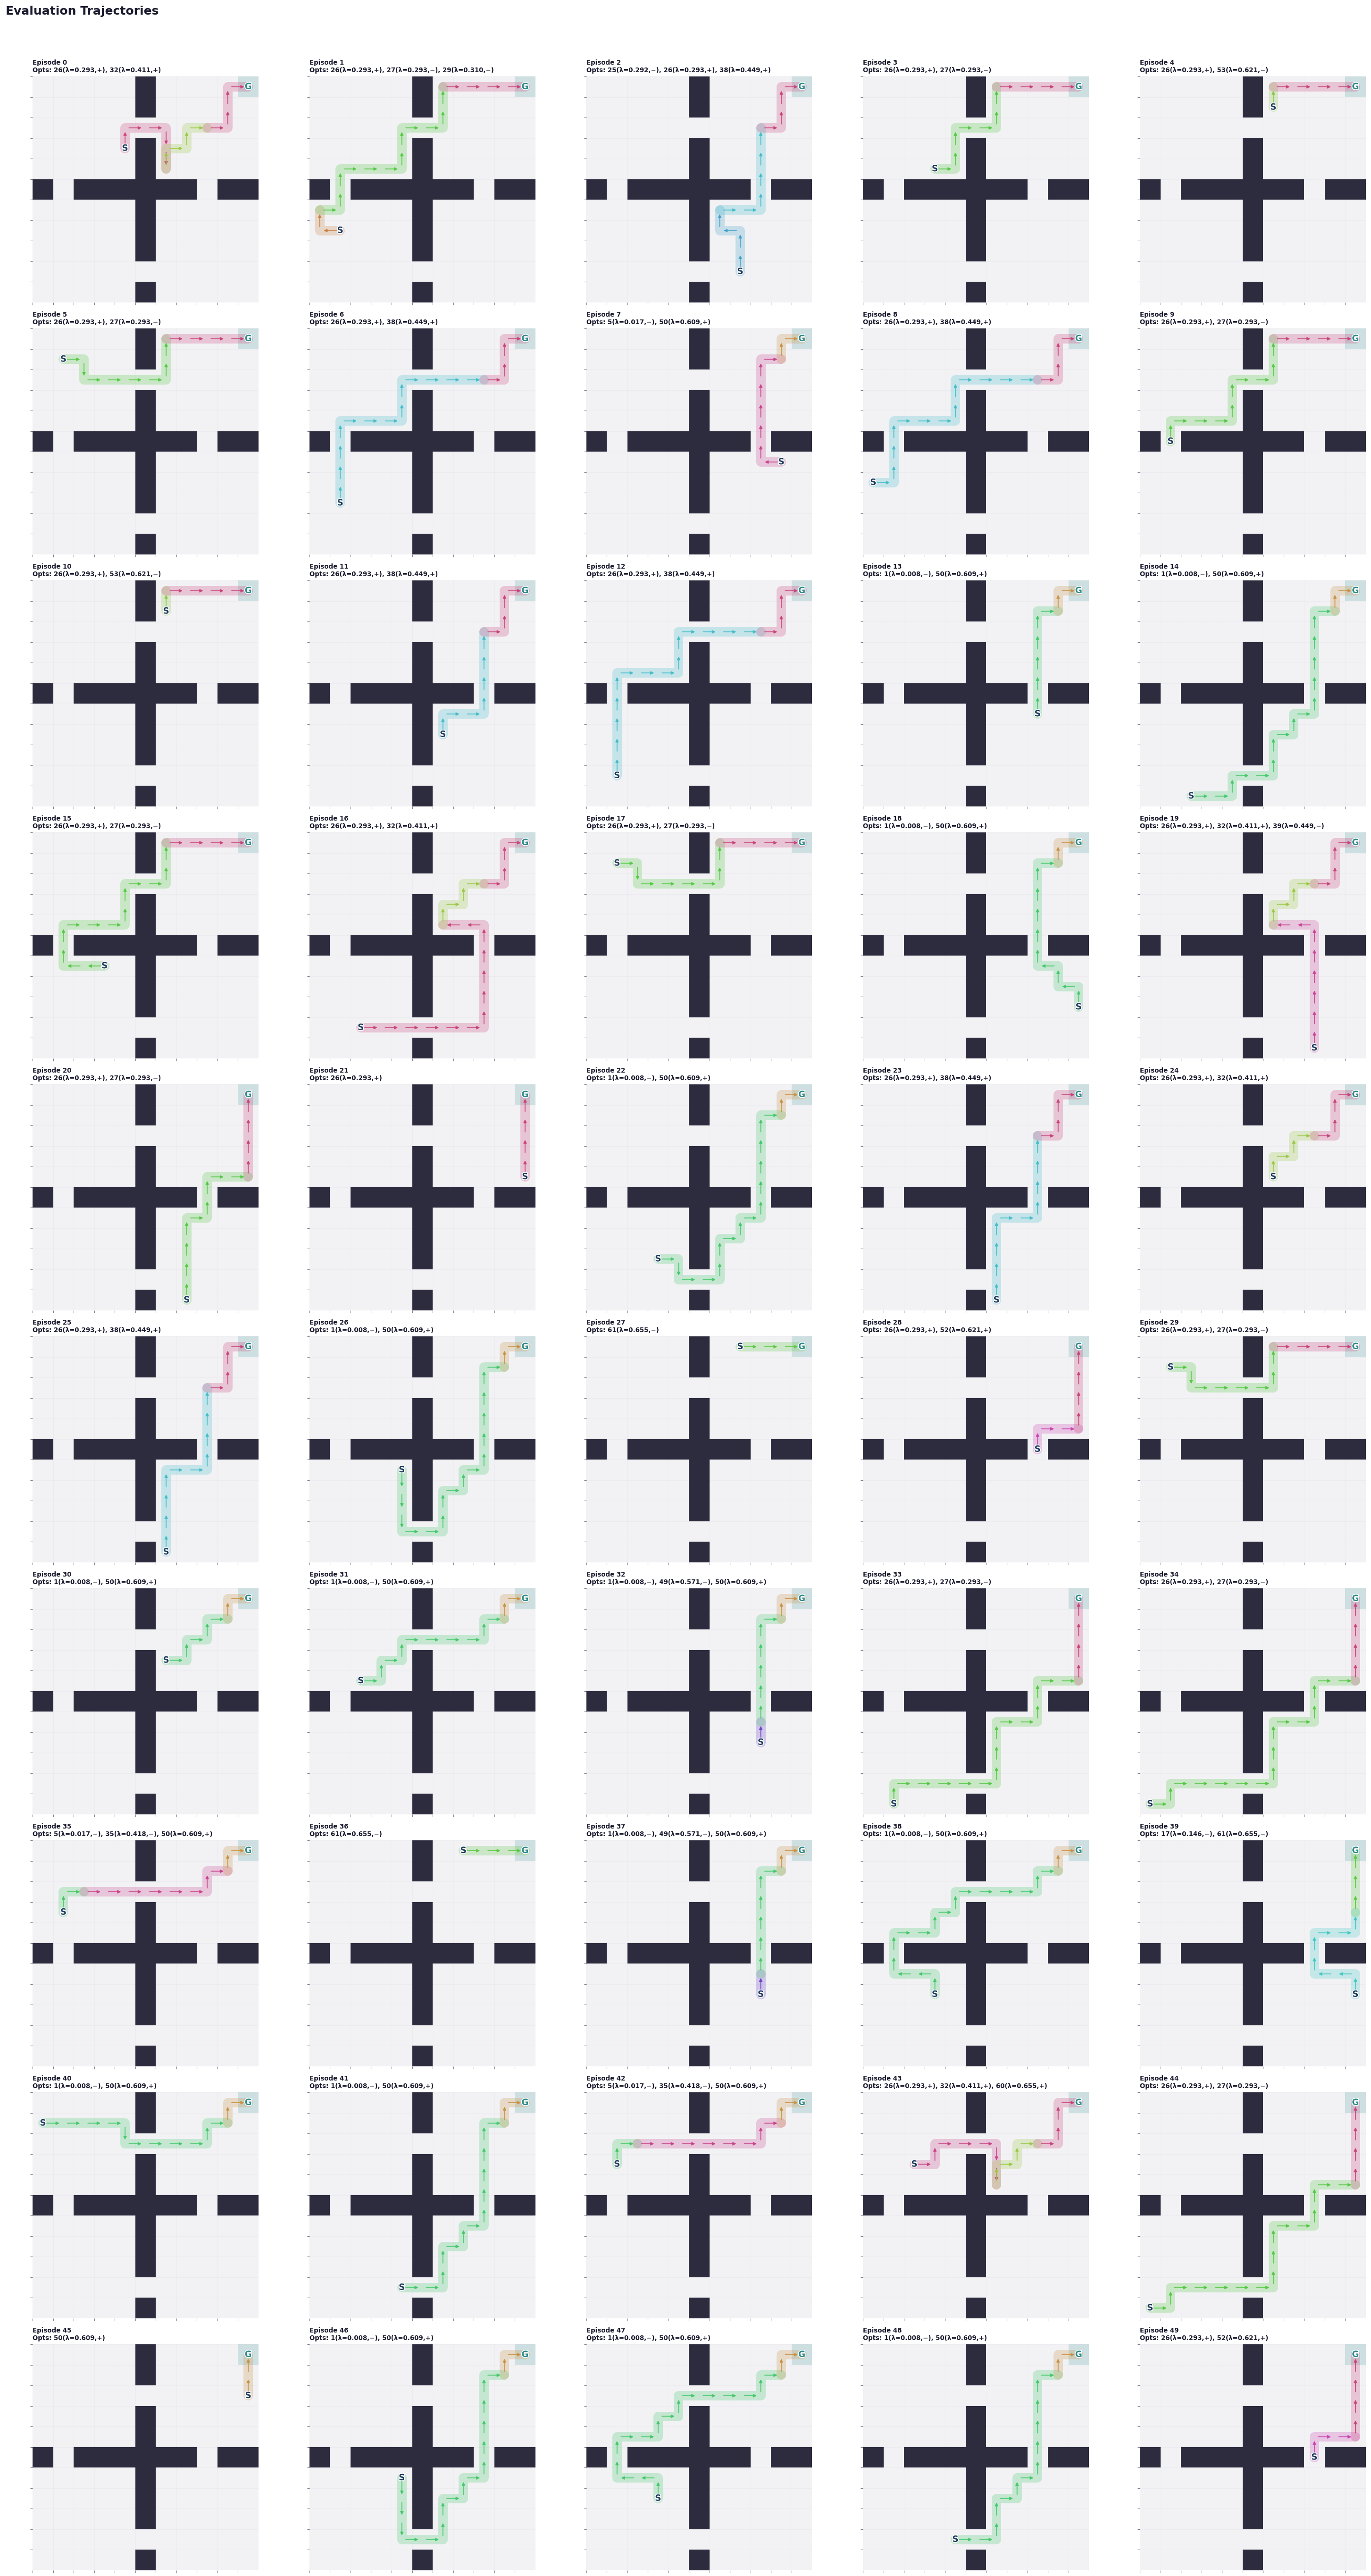

In [73]:
agent_data = {
    'q_table': master_Q_table,
    'options': smdp_options
}

with open('agent.pkl', 'wb') as f:
    pickle.dump(agent_data, f)
print("agent saved to 'agent.pkl'")

\
with open('agent.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

eval_q_table = loaded_data['q_table']
eval_options = loaded_data['options']

NUM_EVAL_EPISODES = 50  
eval_trajectories = {}

eval_env = FourRoomsEnv()

print(f"being greedy on {NUM_EVAL_EPISODES} episodes")

for episode in range(NUM_EVAL_EPISODES):
    eval_env.reset()
    state_idx = eval_env.get_state_idx()
    
    eval_trajectories[episode] = []
    terminated, truncated = False, False
    
    while not (terminated or truncated):
        action = int(np.argmax(eval_q_table[state_idx, :]))
        
        step_record = {
            'high_level_action': action,
            'transitions': []
        }
        
        if action < 4:
            state_coords = eval_env.current_state
            next_obs, reward, terminated, truncated, _ = eval_env.step(action)
            next_state_coords = eval_env.current_state
            
            step_record['transitions'].append((state_coords, next_state_coords))
            state_idx = eval_env.get_state_idx()
            
        else:
            option_idx = action - 4
            option_policy = eval_options[option_idx]['policy']
            
            while not (terminated or truncated):
                if option_policy[state_idx] == 4:
                    break
                    
                prim_action = int(option_policy[state_idx])
                
                state_coords = eval_env.current_state
                next_obs, reward, terminated, truncated, _ = eval_env.step(prim_action)
                next_state_coords = eval_env.current_state
                
                step_record['transitions'].append((state_coords, next_state_coords))
                state_idx = eval_env.get_state_idx()
                
        eval_trajectories[episode].append(step_record)

print("Evaluation complete!")

plot_episode_trajectories(
    eval_trajectories, 
    eval_env, 
    options_list=eval_options,
    start_ep=0, 
    end_ep=NUM_EVAL_EPISODES - 1, 
    save_path="evaluation_trajectories.png"
)

general dashboard to track training data

/tmp/ipykernel_8230/2584477280.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 1])


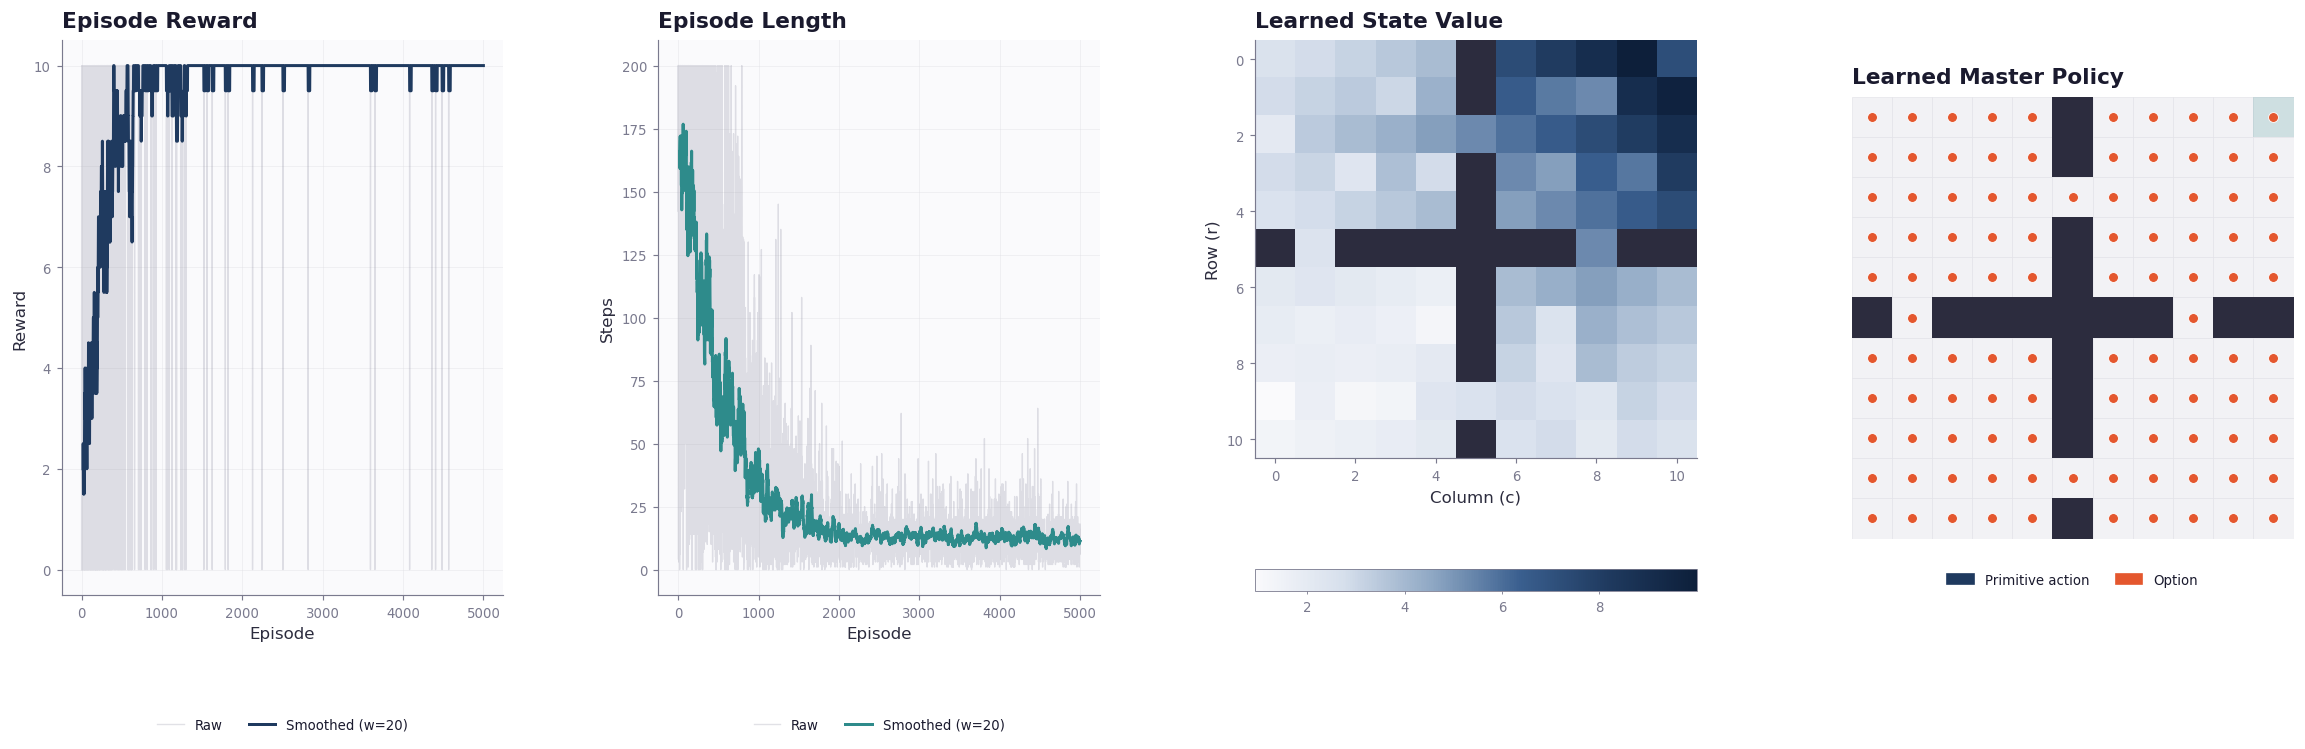

In [74]:
def plot_smdp_results(env, rewards, steps, Q_table, options, window=20):

    smoothed_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')
    smoothed_steps = np.convolve(steps, np.ones(window)/window, mode='valid')

    V = np.max(Q_table, axis=1)
    policy = np.argmax(Q_table, axis=1)
    fig = plt.figure(figsize=(24, 6))
    gs = fig.add_gridspec(1, 4, wspace=0.35)

    #rewards
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(rewards, alpha=PLOT_DEFAULTS["alpha_raw"], color=COLORS["neutral"],
             linewidth=0.8, label='Raw')
    ax1.plot(np.arange(window - 1, len(rewards)), smoothed_rewards,
             color=COLORS["primary"], linewidth=1.8,
             label=f'Smoothed (w={window})')
    set_title(ax1, "Episode Reward")
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Reward")
    style_axes(ax1)
    ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), 
               ncol=2, frameon=False, fontsize=FONT_STACK["legend"]["size"])

    ax2 = fig.add_subplot(gs[0, 1])
    
    #episode steps 
    ax2.plot(steps, alpha=PLOT_DEFAULTS["alpha_raw"], color=COLORS["neutral"],
             linewidth=0.8, label='Raw')
    ax2.plot(np.arange(window - 1, len(steps)), smoothed_steps,
             color=COLORS["secondary"], linewidth=1.8,
             label=f'Smoothed (w={window})')
    set_title(ax2, "Episode Length")
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("Steps")
    style_axes(ax2)
    ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), 
               ncol=2, frameon=False, fontsize=FONT_STACK["legend"]["size"])

    #value heatmap
    ax3 = fig.add_subplot(gs[0, 2])
    grid_V = np.full((env.grid_size, env.grid_size), np.nan)
    for state, idx in env.state_to_idx.items():
        r, c = state
        grid_V[r, c] = V[idx]

    masked_V = np.ma.masked_invalid(grid_V)
    im = ax3.imshow(masked_V, cmap=SEQUENTIAL, aspect='auto',
                    interpolation='nearest')
    set_title(ax3, "Learned State Value")
    style_axes(ax3, grid=False, spines=("left", "bottom"))
    ax3.set_xlabel("Column (c)")
    ax3.set_ylabel("Row (r)")
    cbar = fig.colorbar(im, ax=ax3, orientation="horizontal", fraction=0.046, pad=0.2)
    style_colorbar(cbar)

    #master policy
    ax4 = fig.add_subplot(gs[0, 3])
    draw_env_grid(ax4, env, coord_system="inverted")

    X, Y, U, V_vec = [], [], [], []
    arrow_len = 0.35
    action_to_uv = {
        0: (0.0, +arrow_len),
        1: (+arrow_len, 0.0),
        2: (0.0, -arrow_len),
        3: (-arrow_len, 0.0),
    }

    for state, idx in env.state_to_idx.items():
        r, c = state
        x, y = c, env.grid_size - 1 - r
        action = policy[idx]

        if action < 4:
            du, dv = action_to_uv[action]
            X.append(x)
            Y.append(y)
            U.append(du)
            V_vec.append(dv)
        else:
            ax4.scatter(x, y, color=COLORS["accent"], s=35, zorder=5,
                        edgecolors="white", linewidths=0.5)

    if X:
        ax4.quiver(X, Y, U, V_vec, angles='xy', scale_units='xy', scale=1,
                   color=COLORS["primary"], width=0.005, zorder=4)

    set_title(ax4, "Learned Master Policy")
    prim_patch = mpatches.Patch(color=COLORS["primary"], label="Primitive action")
    opt_patch = mpatches.Patch(color=COLORS["accent"], label="Option")
    # Moved legend outside, bottom center
    ax4.legend(handles=[prim_patch, opt_patch], loc="upper center", 
               bbox_to_anchor=(0.5, -0.05), ncol=2,
               fontsize=FONT_STACK["legend"]["size"], frameon=False)

    #rect instead of square
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

plot_smdp_results(
    train_env,
    smdp_rewards,
    smdp_steps,
    master_Q_table,
    smdp_options, 
)

to visualize individual option policies.

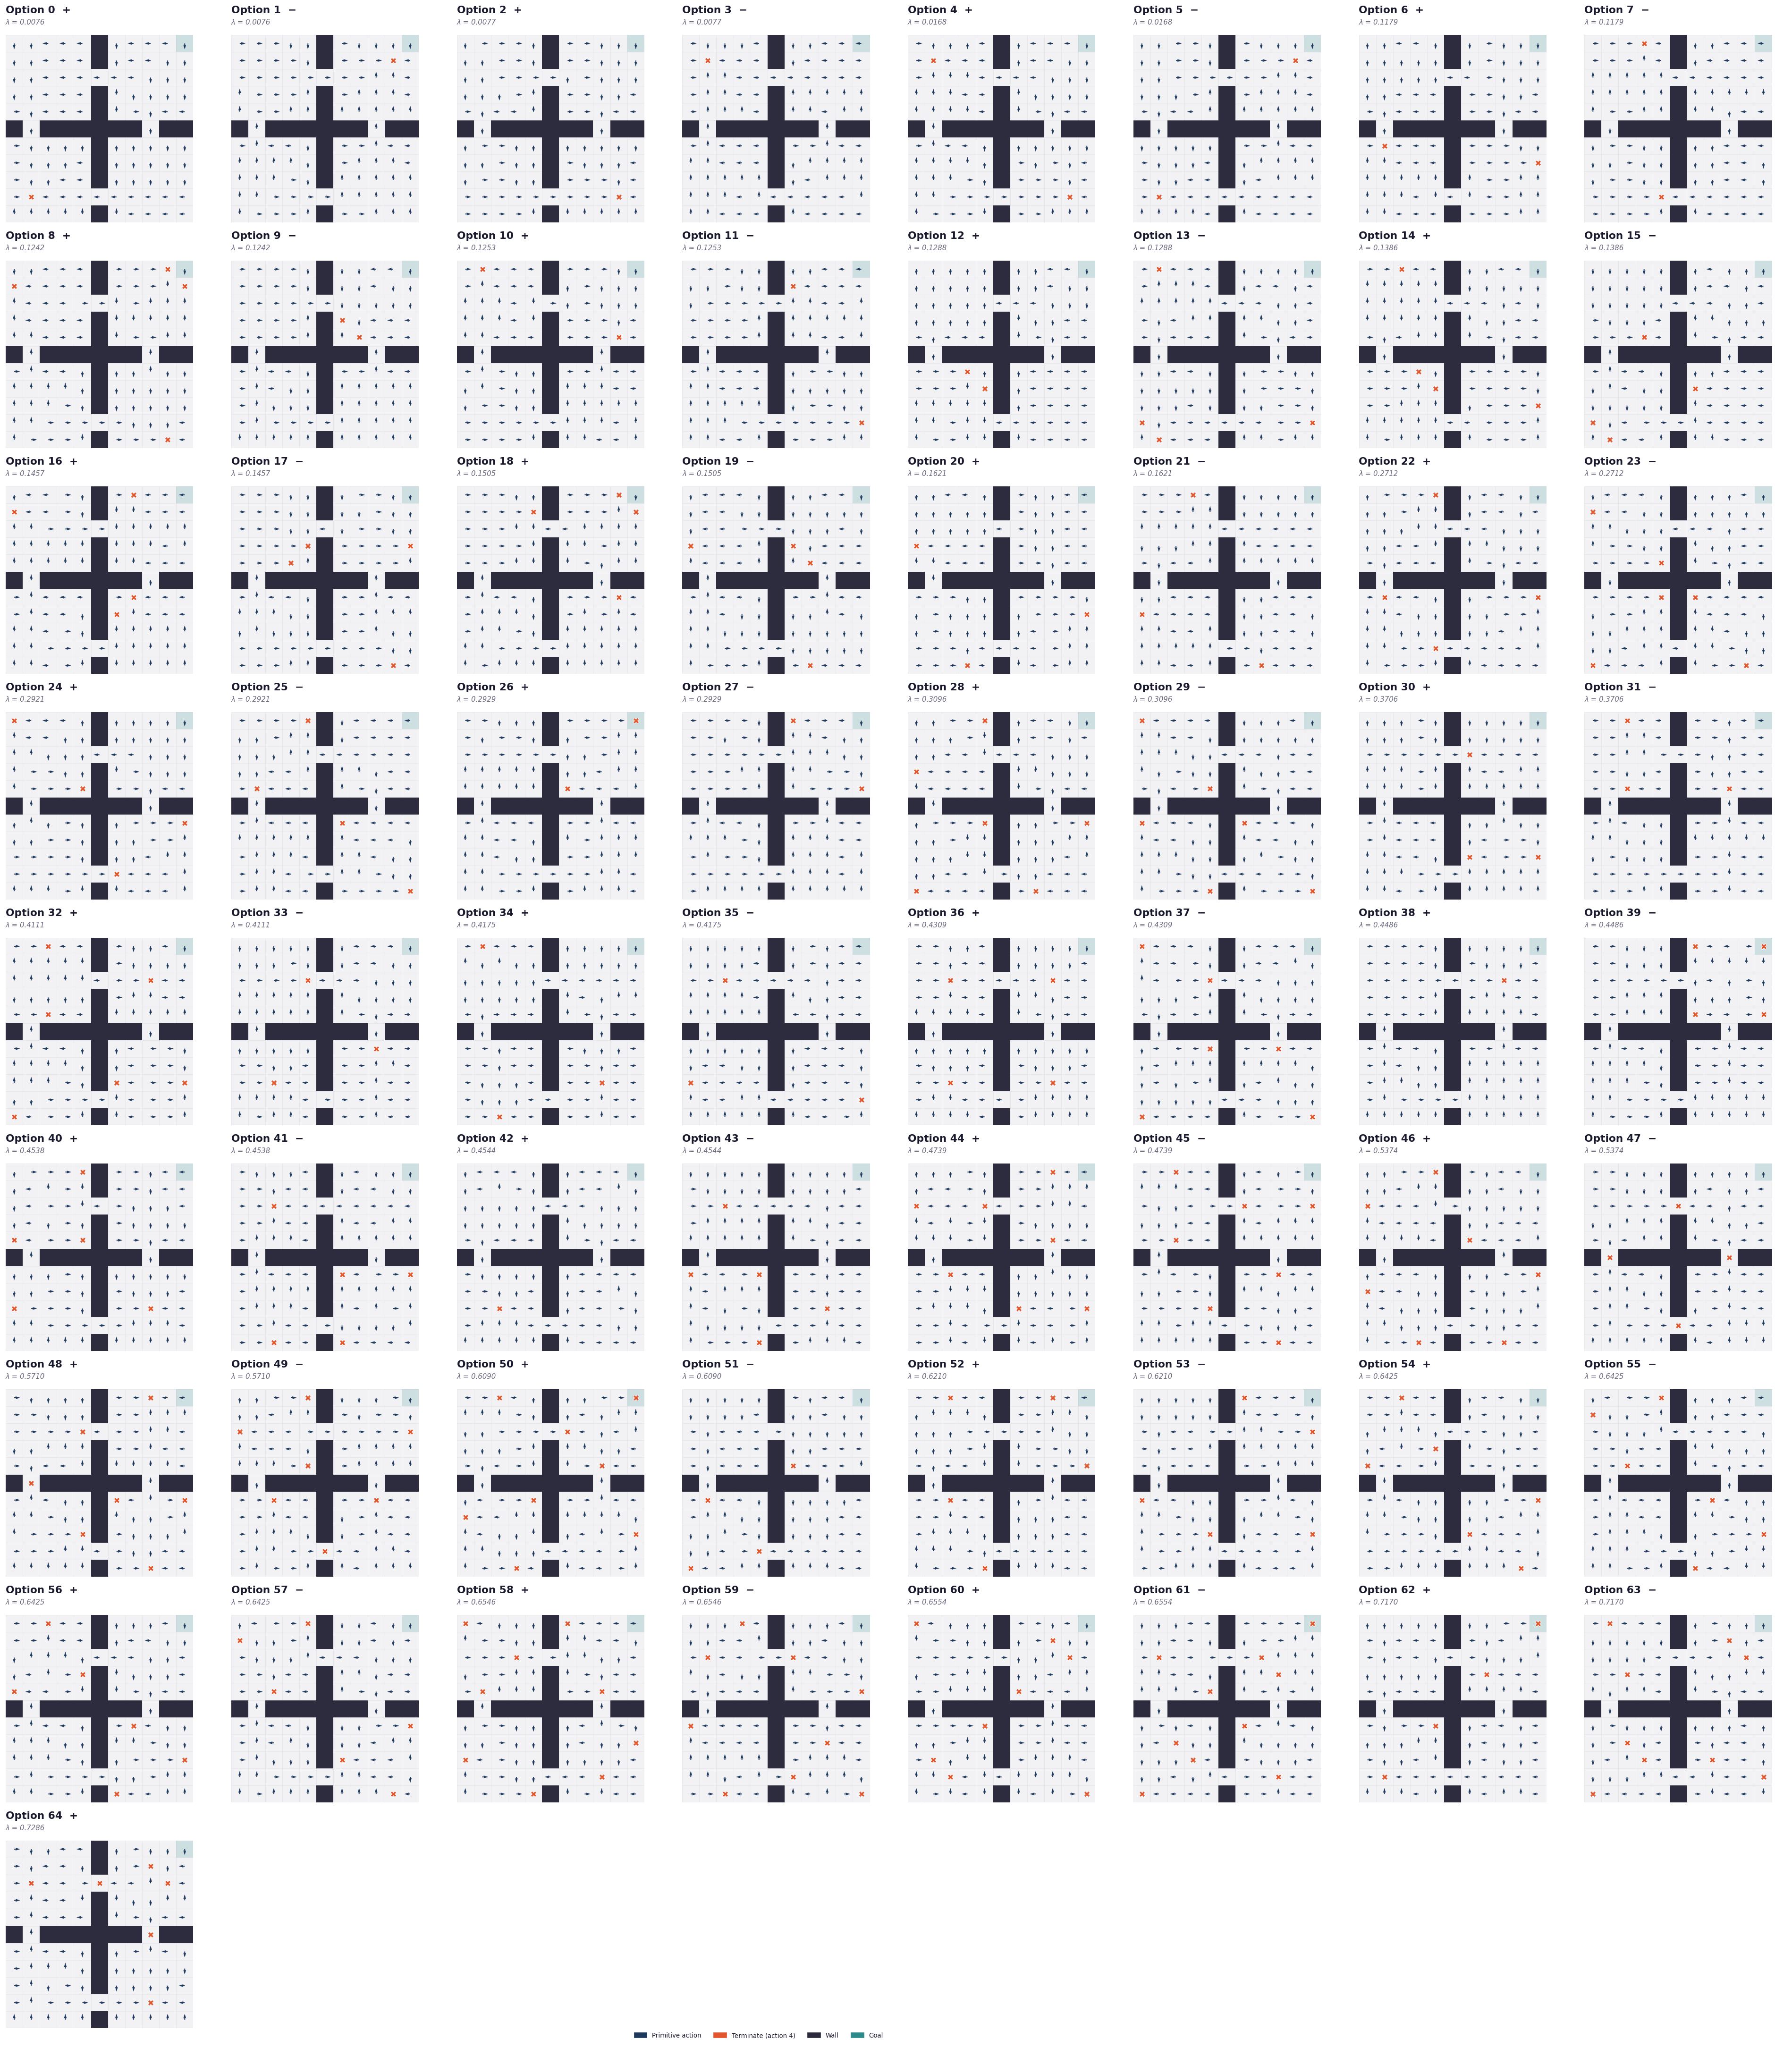

In [75]:
def _draw_eigenoption_on_ax(ax, env, option_data):
    policy = option_data["policy"]
    draw_env_grid(ax, env, coord_system="inverted")

    X, Y, U, V = [], [], [], []
    arrow_len = 0.35

    action_to_uv = {
        0: (0.0, +arrow_len),  # Up
        1: (+arrow_len, 0.0),  # Right
        2: (0.0, -arrow_len),  # Down
        3: (-arrow_len, 0.0),  # Left
    }

    for state, state_idx in env.state_to_idx.items():
        r, c = state
        x = c
        y = env.grid_size - 1 - r
        action = policy[state_idx]

        if action == 4:
            ax.scatter(x, y, color=COLORS["terminate"], marker="X",
                       s=55, zorder=5, edgecolors="white", linewidths=0.5)
        else:
            du, dv = action_to_uv[action]
            X.append(x)
            Y.append(y)
            U.append(du)
            V.append(dv)

    if X:
        ax.quiver(X, Y, U, V, angles="xy", scale_units="xy", scale=1,
                  color=COLORS["primary"], width=0.005, zorder=4)

    direction_sym = "+" if option_data["direction"] == "positive" else "\u2212"
    set_title(ax,
              f"Option {option_data['id']}  {direction_sym}",
              f"\u03bb = {option_data['eigenvalue']:.4f}")


def plot_single_eigenoption(env, options_bank, option_number, figsize=(7, 7)):
    option_data = next((opt for opt in options_bank if opt["id"] == option_number), None)
    if option_data is None:
        raise ValueError(f"Option with id={option_number} not found.")

    fig, ax = plt.subplots(figsize=figsize)
    _draw_eigenoption_on_ax(ax, env, option_data)

    arrow_patch = mpatches.Patch(color=COLORS["primary"], label="Primitive action")
    term_patch = mpatches.Patch(color=COLORS["terminate"], label="Terminate (action 4)")
    wall_patch = mpatches.Patch(color=COLORS["wall"], label="Wall")
    goal_patch = mpatches.Patch(color=COLORS["goal"], label="Goal")
    ax.legend(handles=[arrow_patch, term_patch, wall_patch, goal_patch],
              loc="upper center", bbox_to_anchor=(0.5, -0.02),
              ncol=4, frameon=False, fontsize=FONT_STACK["legend"]["size"])

    fig_title(fig, "Eigenoption Policy",
              f"Option {option_data['id']}  ({option_data['direction']}, "
              f"\u03bb = {option_data['eigenvalue']:.4f})")
    plt.tight_layout(rect=[0, 0.04, 1, 0.94])
    plt.show()


def plot_eigenoptions_grid(env, options_bank, option_numbers, n_cols=8):
    opts_to_plot = []
    for num in option_numbers:
        option_data = next((opt for opt in options_bank if opt["id"] == num), None)
        if option_data is None:
            raise ValueError(f"Option with id={num} not found.")
        opts_to_plot.append(option_data)

    num_plots = len(opts_to_plot)
    n_rows = math.ceil(num_plots / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    
    if num_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, option_data in enumerate(opts_to_plot):
        _draw_eigenoption_on_ax(axes[i], env, option_data)
    
    for j in range(num_plots, len(axes)):
        axes[j].axis("off")

    arrow_patch = mpatches.Patch(color=COLORS["primary"], label="Primitive action")
    term_patch = mpatches.Patch(color=COLORS["terminate"], label="Terminate (action 4)")
    wall_patch = mpatches.Patch(color=COLORS["wall"], label="Wall")
    goal_patch = mpatches.Patch(color=COLORS["goal"], label="Goal")
    
    fig.legend(handles=[arrow_patch, term_patch, wall_patch, goal_patch],
               ncol=4, frameon=False,
               bbox_to_anchor=(0.5, 0.005),
               fontsize=FONT_STACK["legend"]["size"])

    
    plt.tight_layout()
    plt.show()


#for one option
# plot_single_eigenoption(env, options_bank, option_number=8)

#for a range of options.
plot_eigenoptions_grid(env, options_bank, option_numbers=range(65), n_cols=8)

#for passing a custom list 
#plot_eigenoptions_grid(env, options_bank, option_numbers=[0, 10, 20, 30], n_cols=8)

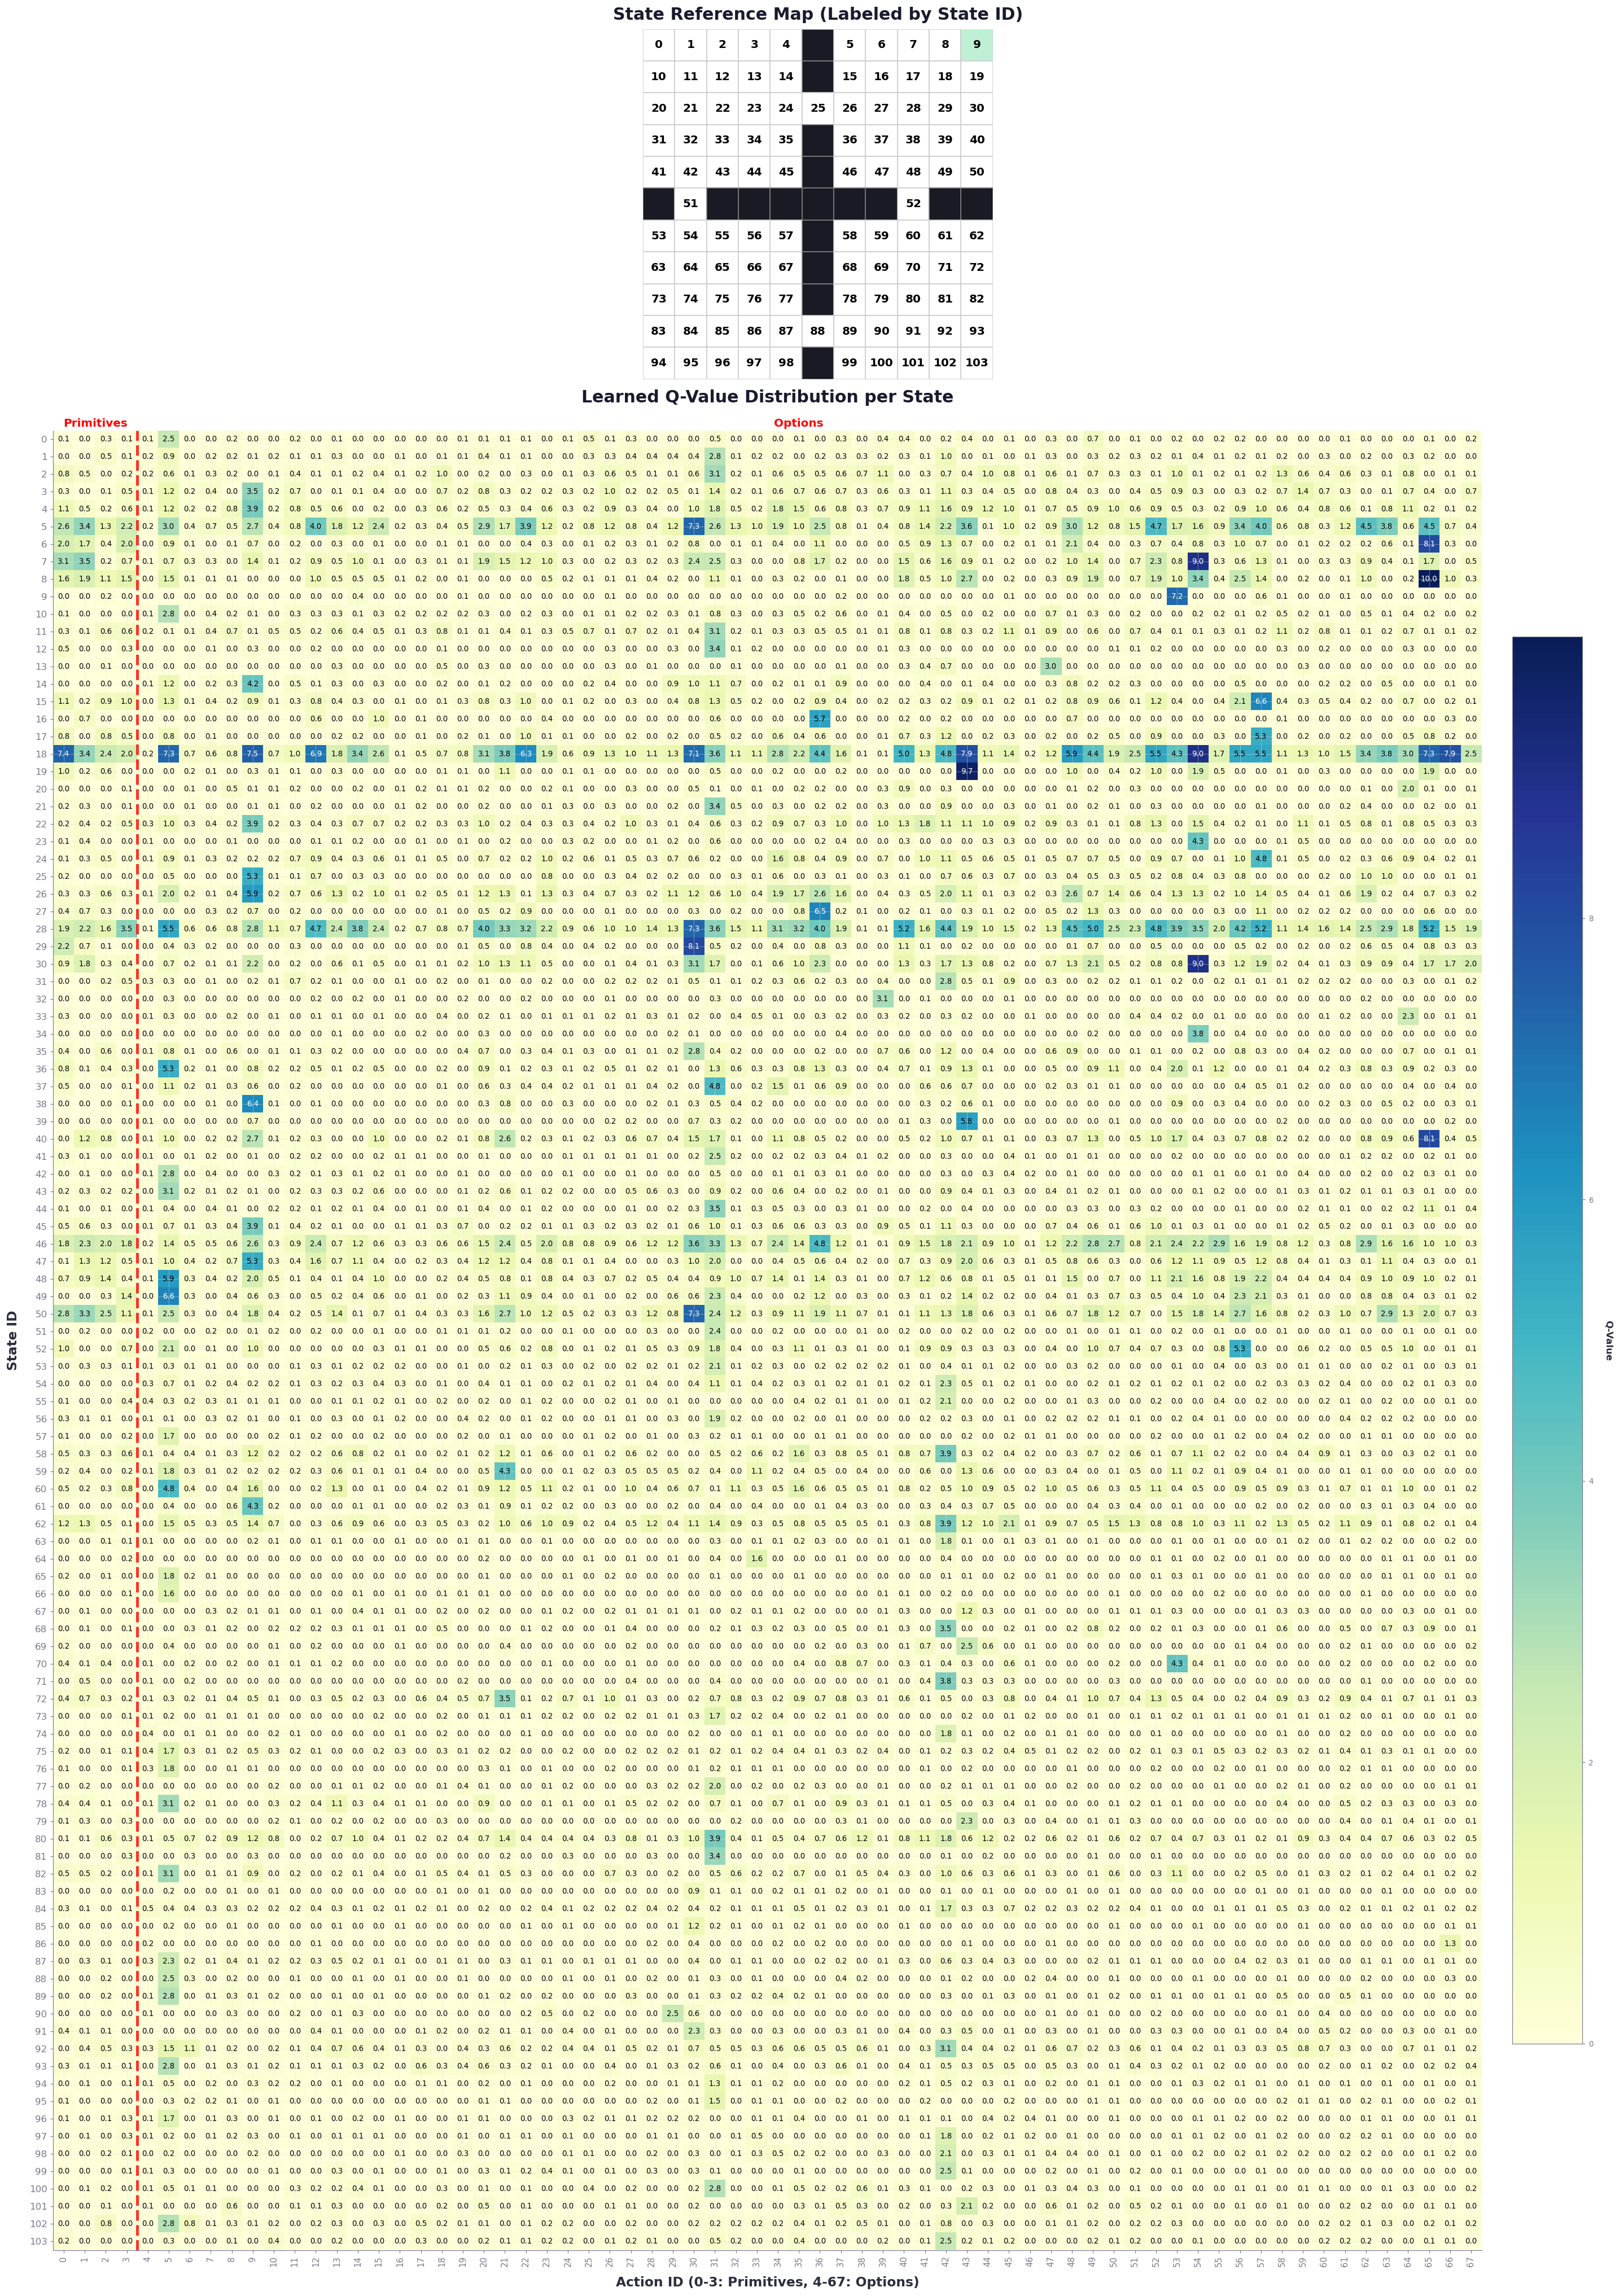

In [ ]:
def plot_q_table_distribution(env, master_Q_table):
    num_states = len(env.state_to_idx)
    num_actions = master_Q_table.shape[1]
    fig_height = 8 + (num_states * 0.25) 
    fig = plt.figure(figsize=(24, fig_height))
    
    #creating layout
    gs = fig.add_gridspec(2, 1, height_ratios=[1, max(2, num_states * 0.05)])
    
    #state map
    ax_grid = fig.add_subplot(gs[0])
    ax_grid.set_xlim(0, env.grid_size)
    ax_grid.set_ylim(0, env.grid_size)
    ax_grid.set_aspect('equal')
    ax_grid.axis('off')
    
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            y = env.grid_size - 1 - r  
            state = (r, c)
            
            #draw walls
            if hasattr(env, 'walls') and state in env.walls:
                rect = mpatches.Rectangle((c, y), 1, 1, facecolor="#1a1a24", edgecolor="gray")
                ax_grid.add_patch(rect)
                
            #draw valid states
            elif state in env.state_to_idx:
                state_id = env.state_to_idx[state]
                
                #if goal state check
                is_goal = hasattr(env, 'goal_state') and state == env.goal_state
                facecolor = "#2ecc71" if is_goal else "white"
                alpha = 0.3 if is_goal else 1.0
                
                rect = mpatches.Rectangle((c, y), 1, 1, facecolor=facecolor, 
                                          edgecolor="#cccccc", alpha=alpha)
                ax_grid.add_patch(rect)
                
                #label cells
                ax_grid.text(c + 0.5, y + 0.5, str(state_id), 
                             color="black", weight='bold', ha='center', va='center', fontsize=12)

    ax_grid.set_title("State Reference Map (Labeled by State ID)", fontsize=18, weight='bold', pad=10)
    
    #q table
    ax_table = fig.add_subplot(gs[1])
    cmap = plt.cm.YlGnBu
    im = ax_table.imshow(master_Q_table, cmap=cmap, aspect='auto', interpolation='nearest')
    vmin, vmax = np.min(master_Q_table), np.max(master_Q_table)
    norm = plt.Normalize(vmin, vmax)
    
    for i in range(num_states):
        for j in range(num_actions):
            val = master_Q_table[i, j]
            
            text_color = "white" if norm(val) > 0.6 else "black"
            ax_table.text(j, i, f"{val:.1f}", ha="center", va="center", 
                          color=text_color, fontsize=8)
    
    # y axis = state IDs
    ax_table.set_yticks(np.arange(num_states))
    ax_table.set_yticklabels([str(i) for i in range(num_states)], fontsize=10)
    ax_table.set_ylabel("State ID", fontsize=14, weight='bold', labelpad=10)
    
    # x axis = action/options
    ax_table.set_xticks(np.arange(num_actions))
    ax_table.set_xticklabels([str(i) for i in range(num_actions)], rotation=90, fontsize=9)
    ax_table.set_xlabel("Action ID (0-3: Primitives, 4-67: Options)", fontsize=14, weight='bold', labelpad=10)
    
    #vertical divider
    ax_table.axvline(x=3.5, color='red', linewidth=3, linestyle='--', alpha=0.8)
    ax_table.text(1.5, -0.6, 'Primitives', color='red', weight='bold', ha='center', va='bottom', fontsize=12)
    ax_table.text(35, -0.6, 'Options', color='red', weight='bold', ha='center', va='bottom', fontsize=12)
    
    #colorbar
    cbar = fig.colorbar(im, ax=ax_table, fraction=0.046, pad=0.02)
    cbar.set_label("Q-Value", rotation=270, labelpad=20, weight='bold')
    
    ax_table.set_title("Learned Q-Value Distribution per State", fontsize=18, weight='bold', pad=30)
    
    plt.tight_layout()
    plt.show()

plot_q_table_distribution(env, master_Q_table)